# Week 10 Lab: Dimensionality Reduction and Clustering

AIE683 Machine Learning, Hacettepe University.

**Case.** A food wholesale distributor in Portugal has 440 business customers. For each one we know the
annual spend in six product categories (fresh, milk, grocery, frozen, detergents/paper, delicatessen).
Marketing wants customer segments, but nobody has labels. We will
1. look at the data with PCA, t-SNE and UMAP,
2. cluster it with k-means, Gaussian mixtures and HDBSCAN,
3. evaluate clusterings with internal (silhouette, BIC) and external (ARI/AMI) measures,
4. log the model-selection sweep to MLflow.

The data has one column we will *not* use for clustering: `Channel` (hotel/restaurant/cafe vs retail).
We only use it afterwards, to check whether the clusters line up with a known business distinction.

Sections marked **Try it** match the in-class activities on the slides. Their TODO cells run as provided;
replace the placeholders with your own code. Expected runtime: about 2 minutes.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"  # limit BLAS/OpenMP threads; set before numpy/sklearn load
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="n_jobs value")  # umap: fixing random_state disables parallelism
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import umap
from sklearn.cluster import HDBSCAN, KMeans
from sklearn.datasets import fetch_openml, load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

np.set_printoptions(precision=3, suppress=True)
SEED = 0

## 1. Load the data
OpenML dataset 1511 (UCI "Wholesale customers"). The six spend columns are `V2`–`V7`; `V1` is the region code.

In [2]:
wholesale = fetch_openml(data_id=1511, as_frame=True)
df = wholesale.frame.rename(columns={"V2": "Fresh", "V3": "Milk", "V4": "Grocery", "V5": "Frozen",
                                     "V6": "Detergents_Paper", "V7": "Delicassen"})
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X_raw = df[spend_cols].astype(float).to_numpy()
channel = df["Channel"].astype(int).to_numpy()  # 1 = HoReCa, 2 = retail; held out
df[spend_cols].describe().round(0)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


Spending is heavily right-skewed (a few very large customers). Distances, PCA and k-means are all
dominated by such values, so we log-transform and then standardize.

In [3]:
preprocess = make_pipeline(FunctionTransformer(np.log1p), StandardScaler())
X = preprocess.fit_transform(X_raw)

## 2. PCA: how many directions matter?

explained variance ratio: [0.441 0.272 0.107 0.101 0.049 0.03 ]
cumulative:               [0.441 0.713 0.82  0.921 0.97  1.   ]


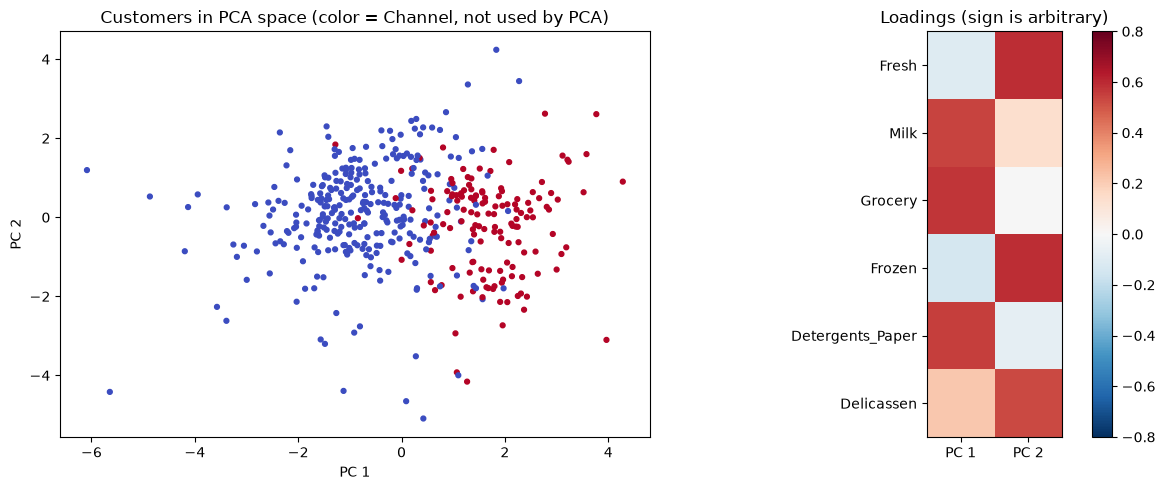

In [4]:
pca = PCA().fit(X)
print("explained variance ratio:", pca.explained_variance_ratio_)
print("cumulative:              ", np.cumsum(pca.explained_variance_ratio_))

X_pca = pca.transform(X)[:, :2]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=channel, cmap="coolwarm", s=12)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].set_title("Customers in PCA space (color = Channel, not used by PCA)")
im = axes[1].imshow(pca.components_[:2].T, cmap="RdBu_r", vmin=-.8, vmax=.8)
axes[1].set_yticks(range(len(spend_cols)), spend_cols)
axes[1].set_xticks([0, 1], ["PC 1", "PC 2"])
axes[1].set_title("Loadings (sign is arbitrary)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()

PC 1 is driven by Grocery, Milk and Detergents_Paper: the "retail-like" basket. Note how well it separates
the two channels even though PCA never saw the channel.

## 3. Clustering: sweep k and log to MLflow
For k-means we record the silhouette score for each k; for Gaussian mixtures we record BIC.
Every configuration becomes an MLflow run, so the sweep is reproducible and comparable across sessions.

In [5]:
mlflow.set_experiment("week10-clustering")
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=SEED).fit(X)
    gmm_labels = gmm.predict(X)
    row = {
        "k": k,
        "kmeans_silhouette": silhouette_score(X, km.labels_),
        "kmeans_inertia": km.inertia_,
        "kmeans_ARI_channel": adjusted_rand_score(channel, km.labels_),
        "gmm_bic": gmm.bic(X),
        "gmm_silhouette": silhouette_score(X, gmm_labels),
        "gmm_ARI_channel": adjusted_rand_score(channel, gmm_labels),
    }
    with mlflow.start_run(run_name=f"k={k}"):
        mlflow.log_params({"k": k, "preprocessing": "log1p+standardize", "gmm_covariance": "full"})
        mlflow.log_metrics({name: value for name, value in row.items() if name != "k"})
    rows.append(row)
sweep = pd.DataFrame(rows).set_index("k")
sweep.round(3)

2026/09/30 00:11:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:11:55 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:11:55 INFO mlflow.tracking.fluent: Experiment with name 'week10-clustering' does not exist. Creating a new experiment.


,kmeans_silhouette,kmeans_inertia,kmeans_ARI_channel,gmm_bic,gmm_silhouette,gmm_ARI_channel
k,,,,,,
2,0.290,1844.064,0.514,6434.362,0.266,0.622
3,0.259,1553.340,0.346,6268.975,0.239,0.431
4,0.188,1386.863,0.280,6312.415,0.165,0.381
5,0.195,1268.136,0.199,6410.553,0.126,0.257
6,0.193,1174.717,0.200,6505.940,0.143,0.244
7,0.196,1086.363,0.209,6596.640,0.122,0.208
8,0.196,1022.890,0.194,6696.825,0.135,0.204


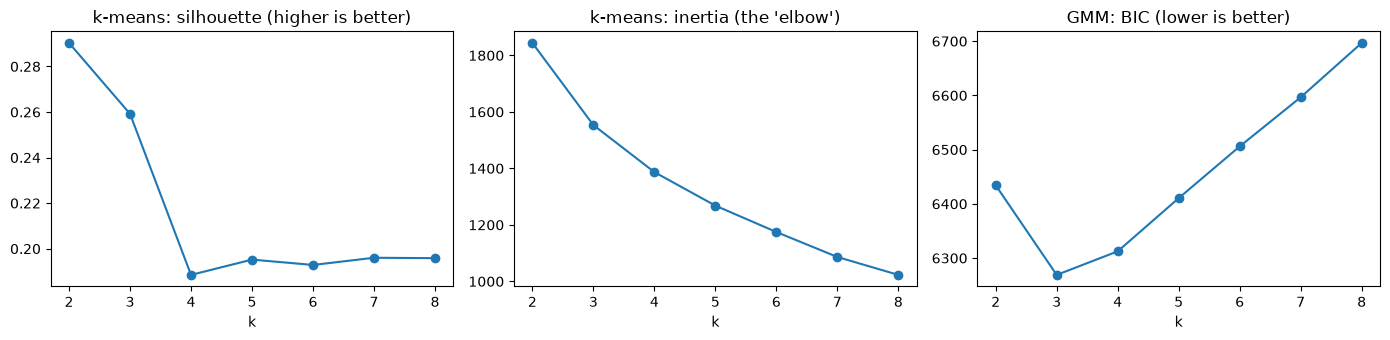

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
sweep["kmeans_silhouette"].plot(ax=axes[0], marker="o", title="k-means: silhouette (higher is better)")
sweep["kmeans_inertia"].plot(ax=axes[1], marker="o", title="k-means: inertia (the 'elbow')")
sweep["gmm_bic"].plot(ax=axes[2], marker="o", title="GMM: BIC (lower is better)")
plt.tight_layout()

In [7]:
# The runs are queryable from the tracking store (browse them with `uv run mlflow ui`).
runs = mlflow.search_runs(experiment_names=["week10-clustering"], order_by=["metrics.kmeans_silhouette DESC"])
runs[["tags.mlflow.runName", "metrics.kmeans_silhouette", "metrics.gmm_bic"]].head()

,tags.mlflow.runName,metrics.kmeans_silhouette,metrics.gmm_bic
0,k=2,0.290328,6434.361570
1,k=3,0.259199,6268.975298
2,k=7,0.196017,6596.639620
3,k=8,0.195843,6696.824779
4,k=5,0.195209,6410.552509


**Reading the sweep.** The internal criteria do not have to agree: silhouette tends to prefer few, well
separated convex groups; BIC trades likelihood against the number of parameters. Neither is "the truth".
The question to ask is which segmentation is useful for the decision at hand.

## 4. Density-based clustering: HDBSCAN
HDBSCAN (in scikit-learn since 1.3) does not need `k` or `eps`. Points that do not belong to a dense
region get the label `-1`: here, customers with an unusual spending profile.

{np.int64(-1): np.int64(367), np.int64(0): np.int64(37), np.int64(1): np.int64(36)}


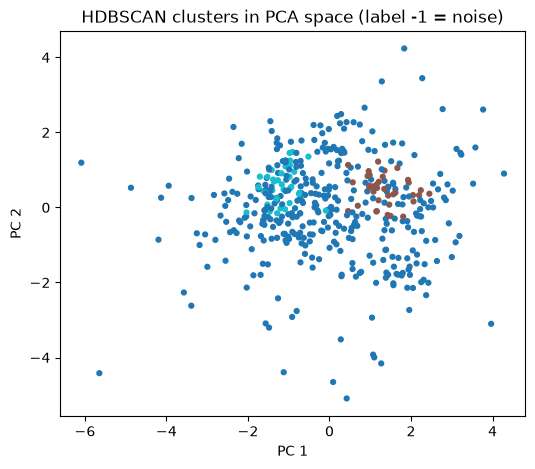

In [8]:
hdb = HDBSCAN(min_cluster_size=15, copy=True).fit(X)
labels, counts = np.unique(hdb.labels_, return_counts=True)
print(dict(zip(labels, counts)))
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=np.where(hdb.labels_ < 0, -1, hdb.labels_), cmap="tab10", s=12)
plt.title("HDBSCAN clusters in PCA space (label -1 = noise)")
plt.xlabel("PC 1")
plt.ylabel("PC 2");

**What happened?** HDBSCAN labels most customers as noise and finds only two small dense groups.
That is an informative answer, not a bug: in the 6-dimensional log-spend space there is no strong
density structure, just one broad cloud with a retail-heavy and a fresh-heavy side. k-means and GMM will
always return k groups, whether or not the data has clusters; density-based methods can say "no".
Try `min_samples=3` to see how sensitive the noise fraction is.

---
## Try it 1: Which map keeps the neighbors?
Dataset: handwritten digits (1797 images, 64 pixels). **Before running anything, predict** which 2D map
(PCA, t-SNE, UMAP) best preserves each point's neighborhood. Then measure it with two numbers:
* `trustworthiness(X, Z, n_neighbors=10)`: are neighbors in the 2D map also neighbors in 64D? (1.0 = perfect)
* 5-fold CV accuracy of a 1-nearest-neighbor classifier trained on the 2D coordinates.

The code runs with PCA only. **TODO:** add t-SNE and UMAP embeddings to `embeddings`, and time them.
Discuss: does the ranking change if you use `n_neighbors=50` in `trustworthiness`? Why is the 1-NN
accuracy on a t-SNE map an optimistic estimate?

In [9]:
digits = load_digits()
X_dig = digits.data / 16.0
y_dig = digits.target

embeddings = {"PCA": PCA(n_components=2, random_state=SEED).fit_transform(X_dig)}
# TODO: add entries, e.g. embeddings["t-SNE"] = ... and embeddings["UMAP"] = ...

results = {}
for name, Z in embeddings.items():
    results[name] = {
        "trustworthiness@10": trustworthiness(X_dig, Z, n_neighbors=10),
        "1NN_cv_accuracy_2d": cross_val_score(KNeighborsClassifier(n_neighbors=1), Z, y_dig, cv=5).mean(),
    }
pd.DataFrame(results).T.round(3)

,trustworthiness@10,1NN_cv_accuracy_2d
PCA,0.83,0.57


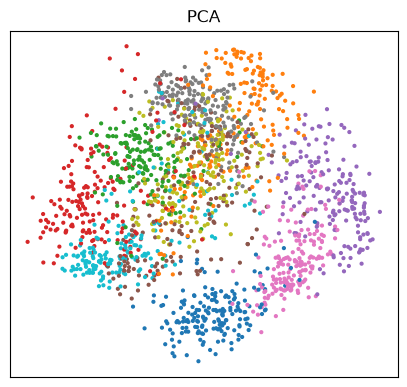

In [10]:
fig, axes = plt.subplots(1, len(embeddings), figsize=(5 * len(embeddings), 4.5), squeeze=False)
for ax, (name, Z) in zip(axes[0], embeddings.items()):
    ax.scatter(Z[:, 0], Z[:, 1], c=y_dig, cmap="tab10", s=4)
    ax.set_title(name)
    ax.set_xticks(())
    ax.set_yticks(())

---
## Try it 2: Segment the customers (small competition)
Back to the wholesale data. Your team proposes a segmentation. Choices you control:
preprocessing (raw, log, log + standardize), algorithm (k-means, GMM, HDBSCAN, agglomerative), and its
parameters. Report **three numbers**: silhouette on *your* preprocessed features, and ARI and AMI against
the held-out `Channel`. Log your final choice to MLflow with the run name set to your team name.

Rules: choose on silhouette/BIC and on whether you can *describe* the segments (look at the median spend
per cluster); peek at ARI only at the end. We compare teams in class, then discuss why a high ARI with
Channel is not the goal of segmentation.

The provided code is a deliberately weak baseline: raw spend, k-means with k=2.

In [11]:
TEAM = "baseline"
# TODO: change the preprocessing and model
X_team = X_raw
model = KMeans(n_clusters=2, n_init=10, random_state=SEED)
team_labels = model.fit_predict(X_team)

mask = team_labels >= 0  # HDBSCAN noise points are excluded from the silhouette
score = {
    "silhouette": silhouette_score(X_team[mask], team_labels[mask]),
    "ARI_channel": adjusted_rand_score(channel, team_labels),
    "AMI_channel": adjusted_mutual_info_score(channel, team_labels),
    "n_clusters": len(set(team_labels[mask])),
}
with mlflow.start_run(run_name=TEAM):
    mlflow.log_param("model", type(model).__name__)
    mlflow.log_metrics(score)
print(score)
# Describe the segments: median annual spend per cluster
df.assign(cluster=team_labels).groupby("cluster")[spend_cols].median().round(0)

{'silhouette': 0.5115333898779053, 'ARI_channel': -0.030608912411094265, 'AMI_channel': 0.007092026552482471, 'n_clusters': 2}


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,30624.0,4411.0,5428.0,3443.0,632.0,1824.0
1,6758.0,3354.0,4563.0,1383.0,836.0,806.0


---
## Pitfall to remember
Internal scores are computed **in the feature space you chose**. A silhouette of 0.6 on raw spend and one
of 0.3 on log-standardized spend are not comparable: the preprocessing changes the geometry that the score
measures. Compare clusterings on the same representation, or judge them by a downstream use.